# Analyse von Boilerplate-Phrasen und Bias im Übersetzungskorpus
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte/Einfache Sprache (LS)

In dieser Untersuchung analysieren wir den Korpus aus `data/corpus/final/` daraufhin, ob systematische Phrasen wie *"Mehr Informationen in Alltagssprache..."*, *"Klicken Sie hier"*, *"Dieser Link führt..."* oder Erwähnungen von Prüfstellen/Forschern (z.B. *"Universität Hildesheim"*, *"Stefan Albers"*) gehäuft in den Zieltexten vorkommen.

Ein solcher Bias in den Trainingsdaten führt dazu, dass generative seq2seq-Modelle diese Phrasen am Ende oder allgemein im Text halluzinieren, was in der qualitativen Analyse der Webanwendung beobachtet wurde.

In [1]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set project root
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


## 1. Laden des Korpus
Wir laden alle JSON-Dateien aus `data/corpus/final/` und extrahieren die Quelltexte (AS) sowie Zieltexte (LS) zusammen mit ihrer Quelle.

In [2]:
json_files = glob.glob("data/corpus/final/*.json")
all_pairs = []

for file_path in json_files:
    source_name = os.path.basename(file_path).replace("_articles.json", "")
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    pairs = data.get("pairs", [])
    for pair in pairs:
        all_pairs.append({
            "source": source_name,
            "ls_url": pair.get("ls_url", ""),
            "as_url": pair.get("as_url", ""),
            "ls_text": pair.get("ls_text", ""),
            "as_text": pair.get("as_text", ""),
            "ls_tokens": pair.get("ls_tokens", 0),
            "as_tokens": pair.get("as_tokens", 0)
        })

df = pd.DataFrame(all_pairs)
print(f"Gesamtzahl der Artikelpaare geladen: {len(df)}")
df.groupby("source").size().reset_index(name="anzahl_artikel")

Gesamtzahl der Artikelpaare geladen: 1476


,source,anzahl_artikel
0,apotheken,157
1,behindertenbeauftragter,51
2,brandeins,18
3,hamburg,56
4,hannover,796
5,koeln,38
6,main_taunus,34
7,mdr,227
8,sozialpolitik,14
9,stuttgart,39


## 2. Definition der Boilerplate-Phrasen und Muster
Wir definieren eine Liste von Phrasen, Mustern und Prüfsiegeln, um nachzuweisen, wo und wie oft diese vorkommen.

In [3]:
phrases_to_check = {
    "Mehr Informationen": ["mehr informationen", "mehr infos", "weitere informationen"],
    "Alltagssprache": ["alltagssprache", "alltags-sprache"],
    "Klicken Sie": ["klicken sie", "klick auf"],
    "Hier finden Sie": ["hier finden sie", "hier gibt es"],
    "Achtung/Wichtig": ["achtung:", "wichtig:"],
    "Link-Warnung": ["dieser link führt", "aus unserem einfache-sprache-angebot", "nicht mehr in einfacher sprache"],
    "Hildesheim": ["hildesheim", "forschungsstelle leichte sprache"],
    "Stefan Albers": ["stefan albers", "atelier fleetinsel"],
    "Inclusion Europe": ["inclusion europe", "easy-to-read logo"],
    "Prüfung/Umsatz": ["geprüft", "prüfung", "prüfer", "übersetzt von", "institut für leichte sprache"]
}

# Erstelle Spalten für jede Phrasengruppe im DataFrame
for category, patterns in phrases_to_check.items():
    df[category] = df["ls_text"].apply(lambda x: any(pattern in x.lower() for pattern in patterns))

# Hat der Artikel mindestens eine Boilerplate-Phrase?
df["has_any_boilerplate"] = df[list(phrases_to_check.keys())].any(axis=1)
print(f"Anteil an Artikeln mit mindestens einer Boilerplate-Phrase: {df['has_any_boilerplate'].mean():.2%}")

Anteil an Artikeln mit mindestens einer Boilerplate-Phrase: 68.16%


## 3. Analyse nach Quelle
Welche Quelle bringt welche Phrasen mit?

In [4]:
source_boilerplate = df.groupby("source")[list(phrases_to_check.keys()) + ["has_any_boilerplate"]].mean()
source_boilerplate_style = source_boilerplate.style.format("{:.1%}").background_gradient(cmap="Reds", axis=0)
source_boilerplate_style

,Mehr Informationen,Alltagssprache,Klicken Sie,Hier finden Sie,Achtung/Wichtig,Link-Warnung,Hildesheim,Stefan Albers,Inclusion Europe,Prüfung/Umsatz,has_any_boilerplate
source,,,,,,,,,,,
apotheken,100.0%,0.0%,1.9%,28.0%,92.4%,100.0%,91.1%,0.0%,0.0%,7.0%,100.0%
behindertenbeauftragter,11.8%,7.8%,3.9%,11.8%,5.9%,0.0%,2.0%,0.0%,0.0%,5.9%,39.2%
brandeins,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
hamburg,35.7%,0.0%,1.8%,8.9%,39.3%,0.0%,0.0%,7.1%,0.0%,19.6%,67.9%
hannover,65.2%,22.6%,54.6%,5.5%,53.3%,0.0%,8.0%,0.0%,0.0%,1.8%,85.2%
koeln,71.1%,18.4%,7.9%,31.6%,65.8%,0.0%,0.0%,97.4%,0.0%,23.7%,100.0%
main_taunus,2.9%,0.0%,5.9%,11.8%,0.0%,0.0%,0.0%,0.0%,0.0%,2.9%,17.6%
mdr,1.3%,0.0%,0.0%,0.0%,1.3%,0.0%,0.0%,0.0%,0.0%,6.6%,8.8%
sozialpolitik,7.1%,0.0%,0.0%,0.0%,7.1%,0.0%,0.0%,0.0%,0.0%,0.0%,14.3%


## 4. Visualisierung der Ergebnisse

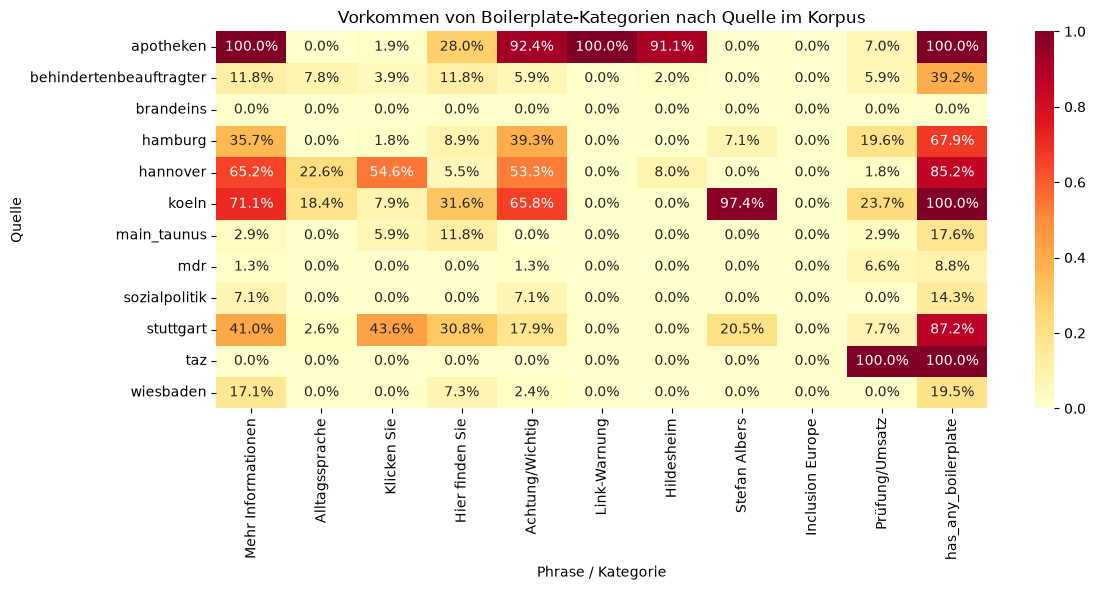

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(source_boilerplate, annot=True, fmt=".1%", cmap="YlOrRd", cbar=True)
plt.title("Vorkommen von Boilerplate-Kategorien nach Quelle im Korpus")
plt.ylabel("Quelle")
plt.xlabel("Phrase / Kategorie")
plt.tight_layout()
plt.show()

## 5. Konkrete Beispiele
Lassen Sie uns ein paar Beispiele anzeigen, wie diese Boilerplates am Ende der Texte aussehen.

In [6]:
for source in df["source"].unique():
    sub = df[(df["source"] == source) & df["has_any_boilerplate"]]
    if not sub.empty:
        print("=" * 80)
        print(f"BEISPIEL AUS QUELLE: {source.upper()}")
        print("=" * 80)
        sample_text = sub.iloc[0]["ls_text"]
        # Zeige die letzten 600 Zeichen des Beispiel-LS-Textes
        print("... " + sample_text[-600:])
        print("\n")

BEISPIEL AUS QUELLE: TAZ
... iben. Das Formular kann man direkt hier oder auf bundeswahlleiter.de herunterladen. Das ausgefüllte Formular sendet man dann zum Beispiel per Post an die Gemeinde am Wohnort. Dort muss das Formular zwischen dem 6. und 10. Mai vorliegen. Zuerst prüft die Gemeinde das Formular. Dann gibt es einen Eintrag im Wähler-Verzeichnis und man darf bei der Europa-Wahl wählen. Die Infos in diesem leichten Text kommen aus diesem „schweren“ Text und vom Bundeswahlleiter. Übertragung in Leichte Sprache von: taz leicht Prüfung von: capito Berlin, Büro für barrierefreie Information Erschienen am: 26. April 2019


BEISPIEL AUS QUELLE: APOTHEKEN
...  finden Sie nur allgemeine Informationen. Die Texte ersetzen die Beratung durch den Arzt nicht. Nur ein Arzt kann Ihnen genaue Informationen geben. Sie fühlen sich krank? Oder Sie haben Fragen zu einer Krankheit? Dann sollten Sie immer mit Ihrem Arzt sprechen. Rufen Sie in der Arztpraxis an. Die Texte haben wir zusammen mit der For